# Phase 2: Internal Representations & Weight Dynamics

While Phase 1 established the behavioral capacity of Backpropagation (BP), PEPITA, and SoftHebb to solve the dataset, this phase analyzes **how** they solve it. Different learning rules can achieve the same accuracy but structure their internal hidden spaces entirely differently.

We will analyze the following key metrics to peek into the "black box" of these models:
1. **Linear Probing:** Evaluates the linear separability of the features at different depths to see if intermediate layers have already solved the classification problem.
2. **Manifold Visualization (PCA):** Projects the high-dimensional hidden representations down to 2D to visually observe how each algorithm disentangles and clusters contradictory inputs.
3. **Representational Similarity (CKA):** Uses Centered Kernel Alignment to quantitatively measure how similar the hidden spaces of BP, PEPITA, and SoftHebb are to one another.
4. **Weight Dynamics & Distributions:** Analyzes the distribution, sparsity, and directional angles (Polar Histograms) of the learned weights to see if the network relies on specialized "concept" neurons or dense, distributed representations.
5. **Activation Sparsity & Dead Neurons:** Analyzes how many neurons actually "fire" (Activation > 0) for a given input.
6. **Class Selectivity Index (CSI):** Measures whether individual neurons act as "concept neurons" by highly correlating their activation with a single specific class label.

In [1]:
import os
import sys
import warnings
import collections
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from IPython.display import display
sys.path.append(os.path.abspath('..'))
from models.baseline_bp import BaselineMLP
from models.pepita import PepitaMLP
from models.softhebb import SoftHebbMLP


warnings.filterwarnings('ignore')

### Load Data and Models
We load the synthetically generated data and the trained weights from Phase 1.

In [2]:
checkpoint_dir = 'checkpoints'

data = torch.load(f'{checkpoint_dir}/synthetic_data.pth', weights_only=False)

X_train_tensor = torch.tensor(data['X_train'], dtype=torch.float32)
y_train_tensor = torch.tensor(data['y_train'], dtype=torch.long)
X_test_tensor = torch.tensor(data['X_test'], dtype=torch.float32)
y_test_tensor = torch.tensor(data['y_test'], dtype=torch.long)

models = {
    'bp': BaselineMLP(),
    'pep': PepitaMLP(),
    'sh': SoftHebbMLP()
}

weight_files = {'bp': 'bp', 'pep': 'pepita', 'sh': 'softhebb'}

for key, model in models.items():
    model.load_state_dict(torch.load(f'{checkpoint_dir}/{weight_files[key]}_weights.pth', weights_only=True))
    model.eval()

bp_model, pep_model, sh_model = models['bp'], models['pep'], models['sh']
print("Models and data loaded successfully.")

Models and data loaded successfully.


### Forward Hooks and Feature Extraction
To analyze the intermediate representations, we need to capture the output of each hidden layer *before* it reaches the final classification head. We do this by attaching PyTorch `forward_hooks` to `fc1` and `fc2` for all three models. 

By applying a ReLU operation to the hooked outputs, we ensure we are studying the exact post-activation signals passed to the next layer.

In [3]:
activations = {'train': {}, 'test': {}}

def get_activation(split, name):
    def hook(model, input, output):
        
        activations[split][name] = np.maximum(0, output.detach().cpu().numpy())
    return hook

def extract_features(X_tensor, split):
    
    for m in [bp_model.fc1, bp_model.fc2, pep_model.fc1, pep_model.fc2, sh_model.fc1, sh_model.fc2]:
        m._forward_hooks = collections.OrderedDict()

    hooks = []
    for prefix, model in zip(['bp', 'pep', 'sh'], [bp_model, pep_model, sh_model]):
        hooks.append(model.fc1.register_forward_hook(get_activation(split, f'{prefix}_fc1')))
        hooks.append(model.fc2.register_forward_hook(get_activation(split, f'{prefix}_fc2')))
    
    with torch.no_grad():
        bp_model(X_tensor)
        pep_model(X_tensor, do_masks=None)
        sh_model(X_tensor)
        
    for h in hooks: 
        h.remove()

extract_features(X_train_tensor, 'train')
extract_features(X_test_tensor, 'test')

train_activations = activations['train']
test_activations = activations['test']

print(f"Train extracted shape for BP FC1: {train_activations['bp_fc1'].shape}")
print(f"Test extracted shape for BP FC1: {test_activations['bp_fc1'].shape}")

Train extracted shape for BP FC1: (1600, 64)
Test extracted shape for BP FC1: (400, 64)


## Metrics:

### Linear Probing
**What it is:** Linear probing involves training a simple, non-deep logistic regression classifier directly on the frozen features of an intermediate layer. 
**Why it matters:** It tells us how linearly separable the data has become at that specific depth. If Layer 1 yields high probing accuracy, it means the network has already successfully transformed the complex manifold into an easily solvable linear space early on.

,Method,Layer,Train Acc,Test Acc
0,BP,FC1,0.999375,1.0000
1,BP,FC2,0.999375,1.0000
2,PEP,FC1,0.997500,0.9975
3,PEP,FC2,0.998750,0.9975
4,SH,FC1,0.997500,0.9975
5,SH,FC2,0.998125,1.0000


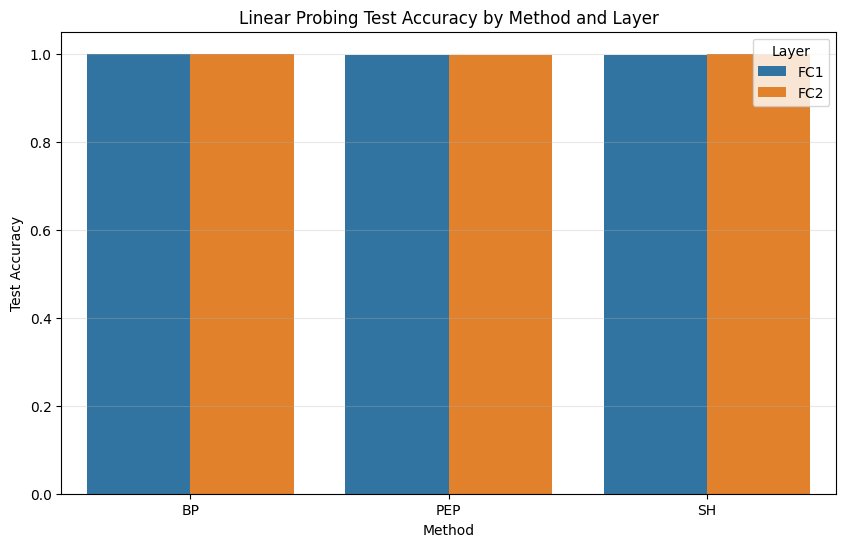

In [4]:
def perform_linear_probing(layer_name):
    X_tr = train_activations[layer_name]
    y_tr = data['y_train'].ravel()
    X_te = test_activations[layer_name]
    y_te = data['y_test'].ravel()
    
    
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_tr_scaled, y_tr)
    
    train_acc = accuracy_score(y_tr, clf.predict(X_tr_scaled))
    test_acc = accuracy_score(y_te, clf.predict(X_te_scaled))
    return train_acc, test_acc

results = []
layers = ['bp_fc1', 'bp_fc2', 'pep_fc1', 'pep_fc2', 'sh_fc1', 'sh_fc2']

for layer in layers:
    tr_acc, te_acc = perform_linear_probing(layer)
    method, l_name = layer.split('_')
    results.append({
        'Method': method.upper(),
        'Layer': l_name.upper(),
        'Train Acc': tr_acc,
        'Test Acc': te_acc
    })

df_probing = pd.DataFrame(results)
display(df_probing)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_probing, x='Method', y='Test Acc', hue='Layer')
plt.title('Linear Probing Test Accuracy by Method and Layer')
plt.ylim(0, 1.05)
plt.ylabel('Test Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Centered Kernel Alignment (CKA)
**What it is:** Linear CKA measures the similarity between two representational spaces (even if they are rotated or scaled differently). A score of 1.0 means the spaces are identical in structure; 0.0 means they are completely orthogonal.
**Why it matters:** It tells us if Backprop, PEPITA, and SoftHebb are converging on the *same* geometric solution, or finding fundamentally distinct ways to map the data.

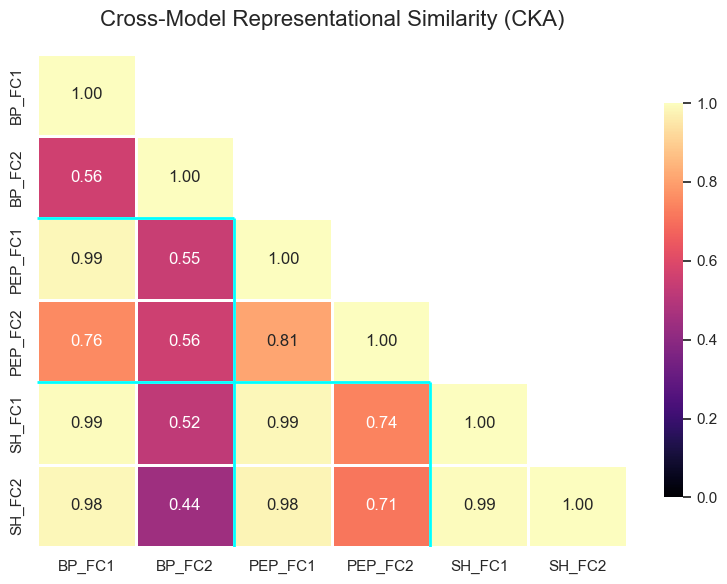

In [5]:
def linear_cka(X, Y):
    X_c = X - X.mean(axis=0)
    Y_c = Y - Y.mean(axis=0)
    XX = X_c @ X_c.T
    YY = Y_c @ Y_c.T
    return np.sum(XX * YY) / (np.linalg.norm(XX, 'fro') * np.linalg.norm(YY, 'fro'))

n_layers = len(layers)
cka_matrix = np.zeros((n_layers, n_layers))

for i, ki in enumerate(layers):
    for j, kj in enumerate(layers):
        cka_matrix[i, j] = linear_cka(test_activations[ki], test_activations[kj])

mask = np.triu(np.ones_like(cka_matrix, dtype=bool), k=1)

plt.figure(figsize=(8, 6))
sns.set_theme(style="white") # Professional paper style

ax = sns.heatmap(
    cka_matrix, mask=mask, annot=True, fmt='.2f', 
    xticklabels=[l.upper() for l in layers], 
    yticklabels=[l.upper() for l in layers], 
    cmap='magma', vmin=0, vmax=1, linewidths=1, linecolor='white',
    cbar_kws={"shrink": .8}
)

# Cyan dividers perfectly constrained to the lower triangle
ax.hlines([2, 4], xmin=0, xmax=[2, 4], colors='cyan', linewidths=2)
ax.vlines([2, 4], ymin=[2, 4], ymax=n_layers, colors='cyan', linewidths=2)

plt.title('Cross-Model Representational Similarity (CKA)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### Manifold Visualization (PCA)
**What it is:** Principal Component Analysis (PCA) compresses the 64-dimensional hidden representations into a 2D plane based on the axes of maximum variance.
**Why it matters:** The input data is highly entangled. By visualizing the hidden representations, we can explicitly see how Backprop vs Local Rules geometrically warp, stretch, and separate the classes as data flows deeper into the network.

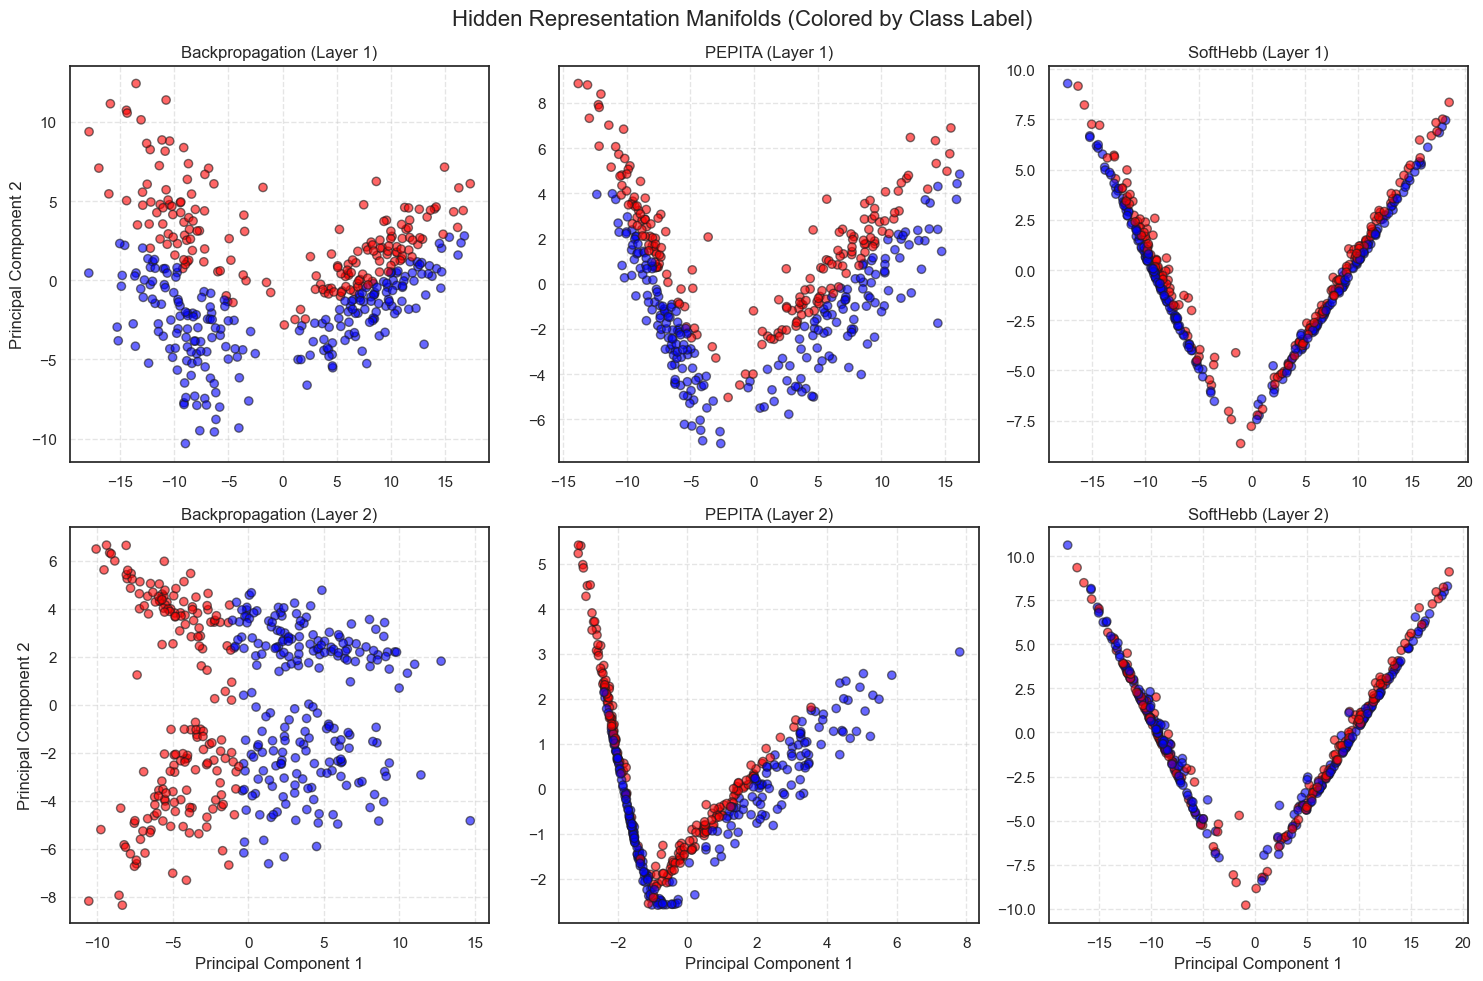

In [6]:
model_prefixes = ['bp', 'pep', 'sh']
model_names = ['Backpropagation', 'PEPITA', 'SoftHebb']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
pca = PCA(n_components=2)

for row, layer_idx in enumerate(['fc1', 'fc2']):
    for col, (prefix, name) in enumerate(zip(model_prefixes, model_names)):
        key = f'{prefix}_{layer_idx}'
        
        
        reduced_features = pca.fit_transform(test_activations[key])
        
        
        axes[row][col].scatter(
            reduced_features[:, 0], 
            reduced_features[:, 1], 
            c=data['y_test'], 
            cmap='bwr', 
            alpha=0.6,
            edgecolor='k', rasterized=True
        )
        axes[row][col].set_title(f'{name} (Layer {row+1})', fontsize=12)
        if row == 1:
            axes[row][col].set_xlabel("Principal Component 1")
        if col == 0:
            axes[row][col].set_ylabel("Principal Component 2")
        axes[row][col].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Hidden Representation Manifolds (Colored by Class Label)", fontsize=16)
plt.tight_layout()
plt.show()

### Weight Angles & Dynamics (Polar Histograms)
**What it is:** We extract the raw weights of the layers and compute their directional angles (in radians), dropping them into a circular (polar) histogram. 
**Why it matters:** This helps us analyze "feature clustering". If the learning rule generates a uniform circular spread, it's exploring all directions equally. If it creates distinct spikes, the method relies on specializing subsets of neurons along specific dominant data axes.

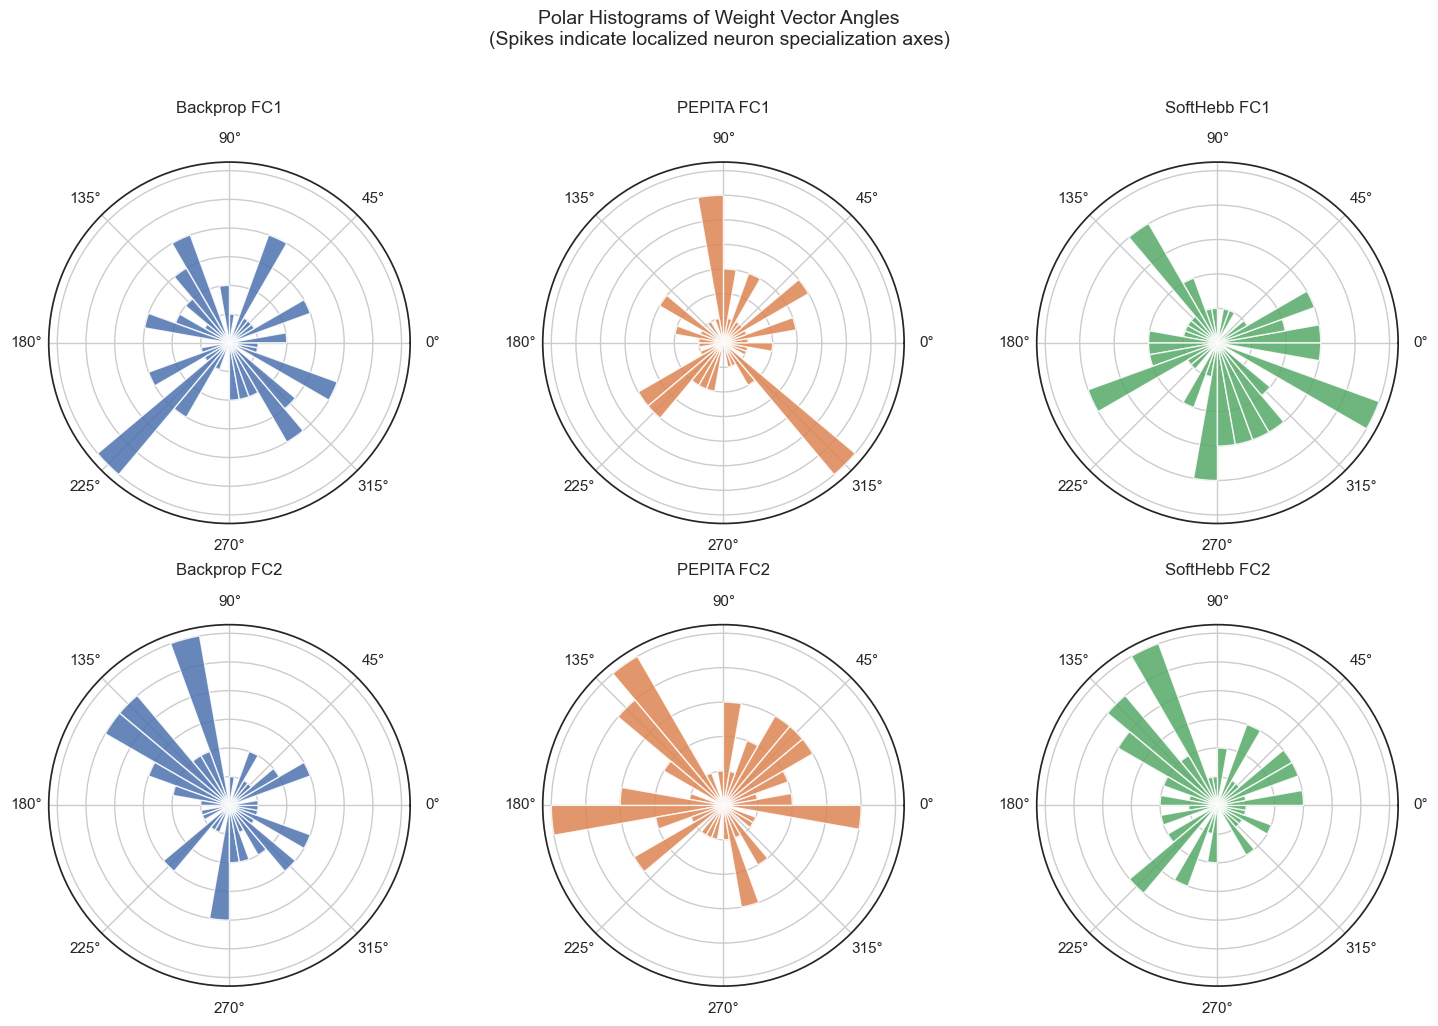

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw={'projection': 'polar'})
model_configs = [('Backprop', bp_model), ('PEPITA', pep_model), ('SoftHebb', sh_model)]
colors = {'Backprop': '#4C72B0', 'PEPITA': '#DD8452', 'SoftHebb': '#55A868'}

N_BINS = 36 
bin_edges = np.linspace(-np.pi, np.pi, N_BINS + 1)
width = 2 * np.pi / N_BINS
centers = (bin_edges[:-1] + bin_edges[1:]) / 2

for row, layer_name in enumerate(['fc1', 'fc2']):
    for col, (method, model) in enumerate(model_configs):
        ax = axes[row, col]
        layer = getattr(model, layer_name)
        
        
        W = layer.weight.detach().cpu().numpy()
        theta = np.arctan2(W[:, 1], W[:, 0]) 
        
        counts, _ = np.histogram(theta, bins=bin_edges)
        
        ax.bar(centers, counts, width=width, color=colors[method], edgecolor='white', alpha=0.85)
        ax.set_title(f'{method} {layer_name.upper()}', fontsize=12, pad=14)
        ax.set_yticklabels([]) 

plt.suptitle('Polar Histograms of Weight Vector Angles\n(Spikes indicate localized neuron specialization axes)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Activation Sparsity & Dead Neurons
**What it is:** We check how many neurons actually "fire" (Activation > 0) for a given input, and flag neurons that *never* fire across the dataset (Dead Neurons).
**Why it matters:** Backprop often relies on dense representations (many neurons fire a little bit). Local rules like SoftHebb naturally encourage sparsity (few neurons fire strongly) but run a higher risk of leaving neurons permanently deactivated.

In [8]:
DEAD_THRESHOLD = 1e-5
sparsity_results = []

for layer_name in layers:
    acts = test_activations[layer_name]
    method, l_name = layer_name.split('_')
    
    
    active_pct = (acts > 0).mean(axis=1) * 100
    
    
    variances = acts.var(axis=0)
    dead_pct = 100 * (variances < DEAD_THRESHOLD).sum() / acts.shape[1]
    
    sparsity_results.append({
        'Method': method.upper(),
        'Layer': l_name.upper(),
        'Mean Active Neurons (%)': active_pct.mean(),
        'Dead Neurons (%)': dead_pct
    })

df_sparsity = pd.DataFrame(sparsity_results)
display(df_sparsity)

,Method,Layer,Mean Active Neurons (%),Dead Neurons (%)
0,BP,FC1,53.003906,0.0000
1,BP,FC2,46.316406,10.9375
2,PEP,FC1,50.613281,0.0000
3,PEP,FC2,43.375000,12.5000
4,SH,FC1,49.656250,0.0000
5,SH,FC2,49.300781,6.2500


### Class Selectivity Index (CSI)
**What it is:** Measures whether individual neurons act as "concept neurons" by highly correlating their activation with a single specific class label.
**Why it matters:** Local learning rules like SoftHebb naturally cluster data, often resulting in highly specialized individual neurons. Backpropagation, conversely, typically relies on distributed representations where meaning is scattered across the entire layer, leading to lower individual selectivity.

,Method,Layer,Mean CSI,Std CSI,% High (>0.5)
0,BP,FC1,0.682,0.116,100.000
1,BP,FC2,0.780,0.257,92.188
2,PEP,FC1,0.705,0.155,100.000
3,PEP,FC2,0.675,0.306,87.500
4,SH,FC1,0.698,0.167,100.000
5,SH,FC2,0.697,0.217,96.875


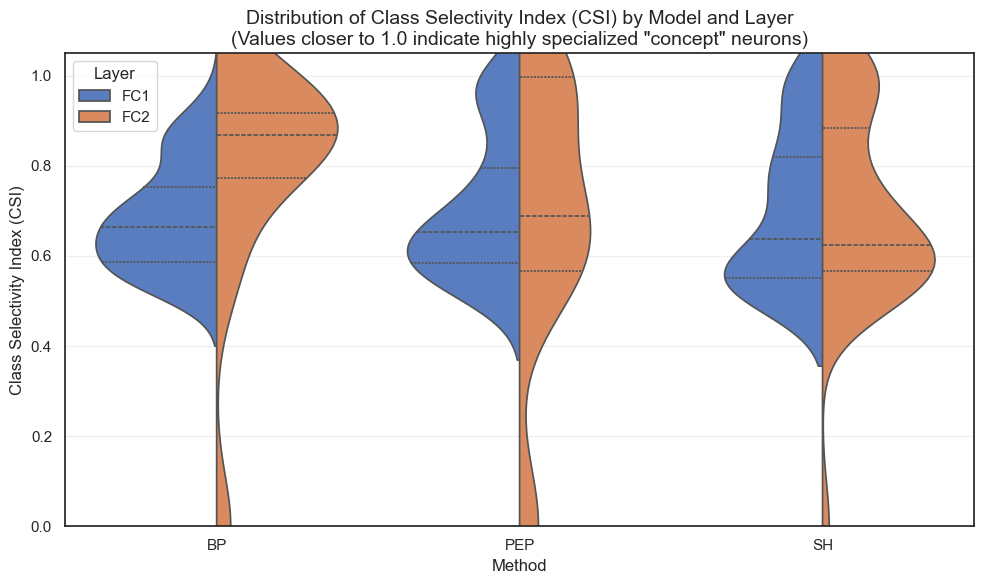

In [9]:
def compute_csi(activations, labels, num_classes):
    
    class_means = np.zeros((num_classes, activations.shape[1]))
    for c in range(num_classes):
        class_means[c] = activations[labels == c].mean(axis=0)
    
    
    class_sum = class_means.sum(axis=0) + 1e-8 
    max_class = class_means.max(axis=0)
    return max_class / class_sum

csi_results = []
csi_raw_data = [] 

num_classes = len(np.unique(data['y_test']))

for layer in layers:
    acts = test_activations[layer]
    method, l_name = layer.split('_')
    
    
    csi = compute_csi(acts, data['y_test'].ravel(), num_classes)
    
    
    csi_results.append({
        'Method': method.upper(),
        'Layer': l_name.upper(),
        'Mean CSI': csi.mean(),
        'Std CSI': csi.std(),
        '% High (>0.5)': (csi > 0.5).mean() * 100
    })
    
    
    for val in csi:
        csi_raw_data.append({
            'Method': method.upper(), 
            'Layer': l_name.upper(), 
            'CSI': val
        })

df_csi = pd.DataFrame(csi_results)
display(df_csi.round(3))

df_csi_raw = pd.DataFrame(csi_raw_data)

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df_csi_raw, 
    x='Method', 
    y='CSI', 
    hue='Layer', 
    split=True, 
    inner='quartile', 
    palette='muted'
)

plt.title('Distribution of Class Selectivity Index (CSI) by Model and Layer\n(Values closer to 1.0 indicate highly specialized "concept" neurons)', fontsize=14)
plt.ylabel('Class Selectivity Index (CSI)')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Layer', loc='upper left')
plt.tight_layout()
plt.show()

### Weight Distributions & Neuron Orthogonality
**What it is:** This dual-plot visualizes the raw spread of the weight values (Histograms) and the Cosine Similarity between the weight vectors of individual neurons within the same layer (Heatmaps).
**Why it matters:** * **Histograms:** Tell us if a learning rule pushes weights to be small and normally distributed (common in BP with weight decay) or creates heavy tails / sparse structures.
* **Cosine Similarity:** Measures redundancy. High values (dark red/blue off the diagonal) mean neurons are learning highly correlated (overlapping) features. A highly orthogonal matrix (mostly white/zero off the diagonal) means the learning rule successfully forced neurons to learn completely independent, distinct concepts to maximize information capacity.

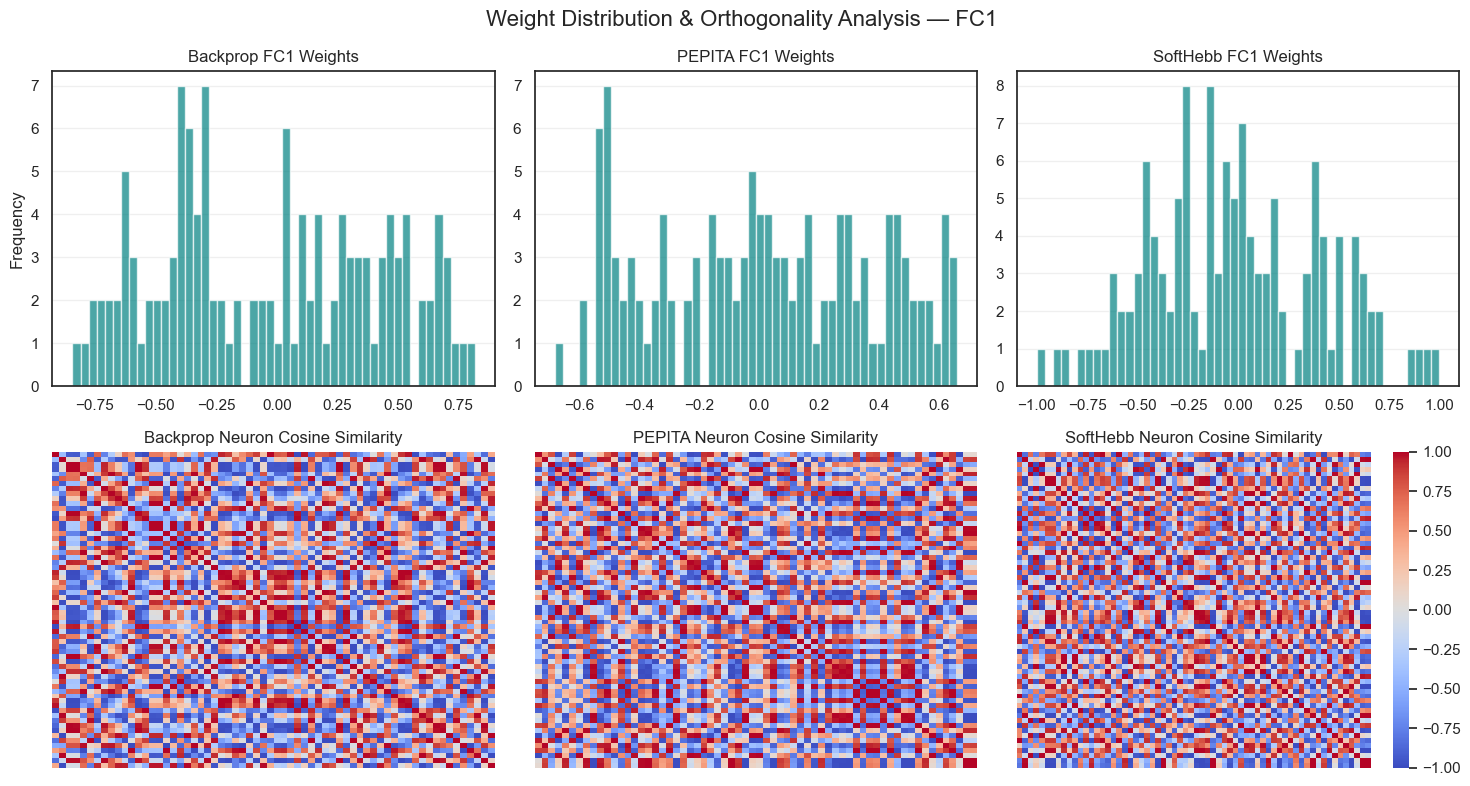

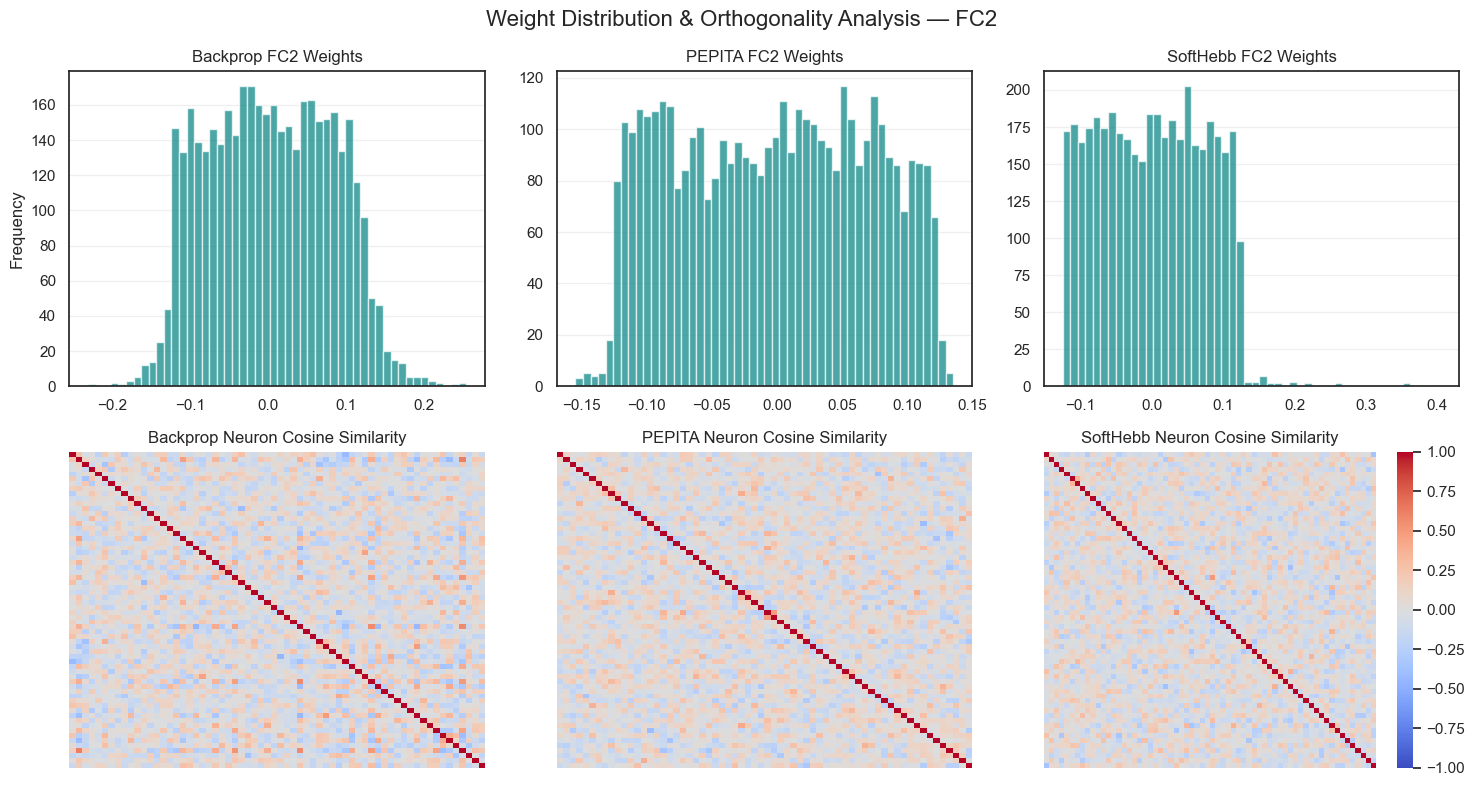

In [10]:
def plot_weight_analysis(layer_name):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    
    
    
    for col, (method, model) in enumerate(model_configs):
        layer = getattr(model, layer_name)
        w_np = layer.weight.detach().cpu().numpy()
        
        
        axes[0, col].hist(w_np.flatten(), bins=50, color='teal', alpha=0.7)
        axes[0, col].set_title(f"{method} {layer_name.upper()} Weights", fontsize=12)
        if col == 0:
            axes[0, col].set_ylabel("Frequency")
        axes[0, col].grid(axis='y', alpha=0.3)
        
        
        
        w_norm = w_np / (np.linalg.norm(w_np, axis=1, keepdims=True) + 1e-8)
        cos_sim_matrix = w_norm @ w_norm.T
        
        
        show_cbar = (col == 2)
        sns.heatmap(
            cos_sim_matrix, 
            ax=axes[1, col], 
            cmap='coolwarm', 
            center=0, 
            cbar=show_cbar, 
            xticklabels=False, 
            yticklabels=False,
            vmin=-1, vmax=1
        )
        axes[1, col].set_title(f"{method} Neuron Cosine Similarity", fontsize=12)

    plt.suptitle(f"Weight Distribution & Orthogonality Analysis — {layer_name.upper()}", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_weight_analysis('fc1')
plot_weight_analysis('fc2')